In [1]:
from parcels import (
    FieldSet,
    JITParticle,
    ScipyParticle,
    ParticleSet,
    AdvectionRK4,
    AdvectionRK4_3D,
    StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta
import dask
from dask.distributed import Client
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from glob import glob
import cartopy
import cartopy.crs as ccrs
import xoak
from time import time
import warnings

import pandas as pd
import seaborn as sns

warnings.simplefilter("ignore")

# Set Parameters

# Plots
- Maps
    - [ ] Monats Aufenthaltswahrscheinlichkeiten
    - [ ] Jahres Aufenthaltswahrscheinlichkeiten
    - [ ] Linen zwischen Stationen
- Connectivitätsmatrix
    - [ ] Monats Averages (logscale)
    - [ ] Jahres Averages (logscale)
    - [ ] Einzelne Jahre

In [2]:
site_counter = np.arange(6,7)
years = np.arange(2016,2017)
ds_trajectories = xr.Dataset()
for sc in site_counter:
    for year in years:
        if (year == min(years)) & (sc == min(site_counter)):
            ds_trajectories = xr.open_zarr(
                f"/gxfs_work/geomar/smomw597/2025_copepod_dispersal/output/PPmill_Nested_{year}0601-{year}1101_dt15min_site{sc:02d}_d0m-25m_N1000_seed123.zarr"
            ).assign_coords({"site":sc}).expand_dims({"site":site_counter})
            age_mask = ((ds_trajectories.age_sec/(60*60*24)).compute() > 10)
            # age_mask = ((ds_trajectories.age_sec/(60*60*24)).compute() > 25)
            ds_trajectories = ds_trajectories.where(age_mask, drop = True)
        else:
            ds_load = xr.open_zarr(
                    f"/gxfs_work/geomar/smomw597/2025_copepod_dispersal/output/PPmill_Nested_{year}0601-{year}1101_dt15min_site{sc:02d}_d0m-25m_N1000_seed123.zarr"
                ).assign_coords({"site":sc}).expand_dims({"site":site_counter}).where(age_mask, drop = True)
            ds_trajectories = xr.concat(
                [
                    ds_trajectories,
                    ds_load
                ],
                dim="trajectory",
            )

ds_trajectories = (
    ds_trajectories
    # .isel(obs=slice(-100, None), trajectory=slice(None, None, 7000))
    # .isel(trajectory=slice(1000))
    .chunk(chunks={'trajectory':100000,'obs':100})
)#.compute() 
ds_trajectories

<xarray.Dataset> Size: 21GB
Dimensions:     (site: 1, trajectory: 143000, obs: 2049)
Coordinates:
  * site        (site) int64 8B 6
  * obs         (obs) int32 8kB 640 641 642 643 644 ... 2684 2685 2686 2687 2688
  * trajectory  (trajectory) int64 1MB 0 1 2 3 4 ... 142996 142997 142998 142999
Data variables: (12/14)
    S           (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    T           (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    age_sec     (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    d           (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    eta         (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    h0          (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    ...          ...
    time        (site, trajectory, obs) datetime64[ns] 2GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    u           (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    v           (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    wsigma      (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    wz          (site, trajectory, obs) float32 1GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
    z           (site, trajectory, obs) float64 2GB dask.array<chunksize=(1, 100000, 100), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_3D_SIGMABSHAgingDeleteErr...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [3]:
# age_mask = ((ds_trajectories.age_sec/(60*60*24)).compute() > 10)

In [4]:
# ds_depth = ds_trajectories.drop(
#         ("S", "T", "age_sec", "d", "lat", "lon", "time", "u", "v", "wsigma", "wz")
#     )
# print(ds_depth.nbytes/1e9)
# ds_depth

# depth_m = (
#         ds_depth.eta - ds_depth.z * (ds_depth.eta + ds_depth.h0)
#     ).compute()
# depth_m

In [5]:
ds_positions = ds_trajectories.drop(
        ("S", "T", "age_sec", "d", "eta", "h0", "time", "u", "v", "wsigma", "wz", "z")
    ).compute()
print(ds_positions.nbytes/1e9)
ds_positions

4.689264204


<xarray.Dataset> Size: 5GB
Dimensions:     (site: 1, trajectory: 143000, obs: 2049)
Coordinates:
  * site        (site) int64 8B 6
  * obs         (obs) int32 8kB 640 641 642 643 644 ... 2684 2685 2686 2687 2688
  * trajectory  (trajectory) int64 1MB 0 1 2 3 4 ... 142996 142997 142998 142999
Data variables:
    lat         (site, trajectory, obs) float64 2GB nan nan nan ... nan nan nan
    lon         (site, trajectory, obs) float64 2GB nan nan nan ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_3D_SIGMABSHAgingDeleteErr...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

# Analysis

## Maps

In [6]:
first_timestep = (
    age_mask
    .isel(trajectory=12)
    .where(age_mask.isel(trajectory=12)==1, drop = True)
    .squeeze()
    .obs
    .min()
    .values
)
first_timestep

array(959, dtype=int32)

In [7]:
last_valid_obs = ds_positions.obs.where(ds_positions.lon.notnull()).max('obs').astype(int)
last_valid_obs_corrected = (last_valid_obs-first_timestep).where(last_valid_obs-first_timestep>0, 0)
last_step = ds_positions.isel(obs=last_valid_obs_corrected).compute()

last_lon = last_step.lon.dropna("trajectory")
last_lat = last_step.lat.dropna("trajectory")

last_step.to_dataframe().describe()

,lat,lon,obs
count,143000.000000,143000.000000,143000.000000
mean,54.546465,10.290534,1780.461538
std,0.165696,0.597987,451.664254
min,53.946963,9.430550,640.000000
25%,54.470251,10.001537,1473.000000
50%,54.508451,10.051777,1788.000000
75%,54.550049,10.304095,2172.000000
max,57.821048,14.702690,2369.000000


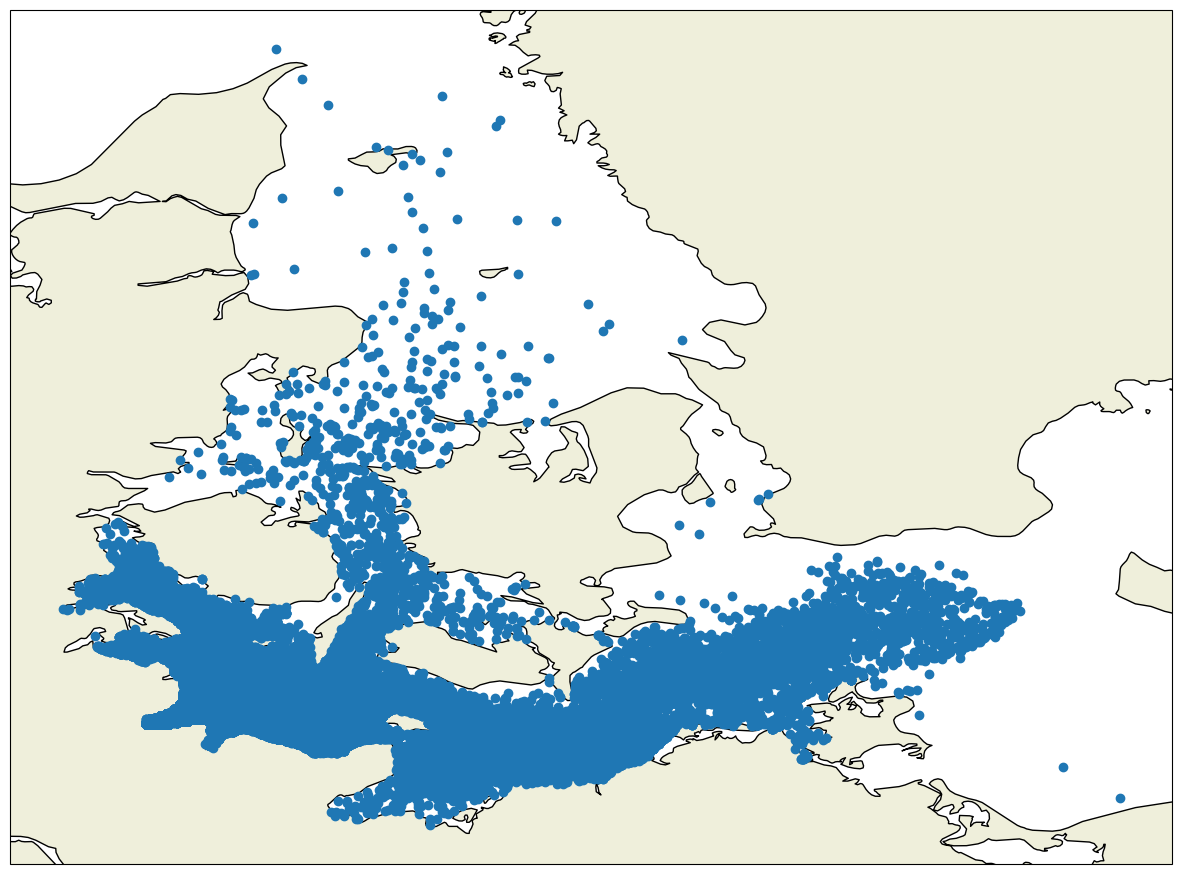

In [8]:
fig = plt.figure(figsize=(15,12))
ax = fig.add_subplot(
    1,1,1,
    projection= ccrs.PlateCarree(),
)
ax.add_feature(cartopy.feature.LAND, edgecolor='k')
ax.scatter(
    last_lon,
    last_lat,
    transform=ccrs.Geodetic(),
)
plt.show()

ValueError: too many values to unpack (expected 2)

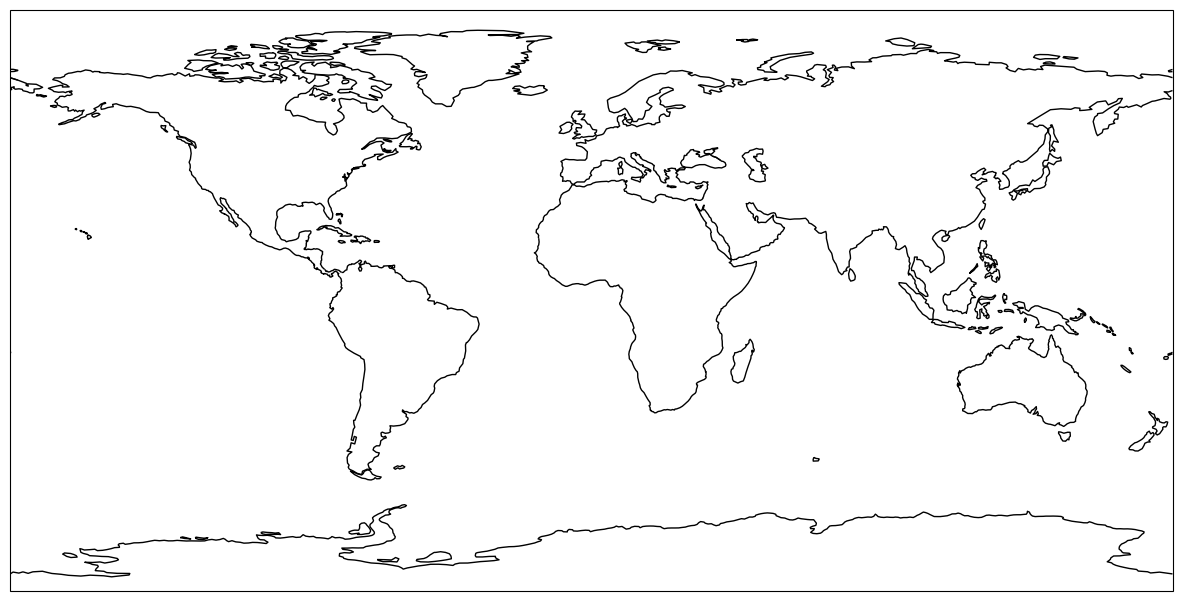

In [10]:
fig, ax = plt.subplots(
    1,1,
    subplot_kw={'projection' : ccrs.PlateCarree()},
    figsize=(15,12),
)
ax.coastlines()
dense_plt = ax.hist2d(
    last_lon,
    last_lat,
    bins=[100, 100],
    norm=mcolors.LogNorm(),
    cmap=cmocean.cm.amp,
)
fig.colorbar(
    dense_plt[3],
    ax=ax,
    extend="max",
    label="density",
)
plt.show()

In [11]:
samples = [
    "Speicherkoog", "KB03", "SW08",
    "Wilhelmshaven", "GB96", "H21",
    "Boknis_Eck", "Gdynia", "Riga",
    "IU7_c", "LL17_c", "Finland",
    "BB23", "BB36", "Speicherkoog_Außen",
    "Wilhelmshaven_Außen",
]
lats = [
    54.0929, 54.692, 54.413,
    53.513, 56.54, 54.666,
    54.5169, 54.5829, 57.3911,
    59.489, 59.02, 59.77,
    55.1751, 54.575, 54.11,
    53.637,
]
lons = [
    8.9487, 10.1035, 11.617,
    8.149, 19.5809, 13.0224,
    10.034, 18.6042, 23.8588,
    21.2021, 21.0478, 23.2663,
    15.4352, 16.001, 8.5,
    8.15,
]
# lats = [54.0929, 54.692, 54.413, 53.513, 56.54, 54.666, 54.3101, 54.5329, 57.3911, 59.489, 59.02, 59.7766, 55.1751, 54.575]
# lons = [8.9487, 10.1035, 11.617,8.149,19.5809,13.0224,10.0201,18.5642,23.8588,21.2021,21.0478,23.2663,15.4352,16.001]

number_sites = len(samples)
number_years = len(years)
dist = 10

In [12]:
connectivity_matrix = np.zeros((number_sites, number_sites), dtype=int)
connected_stations_dict = {}
connectivity_per_year = np.zeros((number_years, number_sites, number_sites))

In [13]:
def connectivity_function(
    ds=None,
    dist=None,
):
    # Mean radius of the Earth in km
    R = 6371  

    # Stations (targets)
    obs_lon_deg = ds_traj.lon
    obs_lat_deg = ds_traj.lat
    obs_lon_km = R * np.cos(np.radians(obs_lat_deg)) * np.radians(obs_lon_deg)
    obs_lat_km = R * np.radians(obs_lat_deg)

    # Particles
    target_lon_deg = xr.DataArray(lons)
    target_lat_deg = xr.DataArray(lats)
    target_lon_km = R * np.cos(np.radians(target_lat_deg)) * np.radians(target_lon_deg)
    target_lat_km = R * np.radians(target_lat_deg)

    # Calculate distance to target
    distance_to_target = (
        ((obs_lon_km - target_lon_km) ** 2) + ((obs_lat_km - target_lat_km) ** 2)
    ) ** 0.5

    # Return number of particles within a certain distance from target
    return (distance_to_target <= dist).sum(dim=["obs", "trajectory"]).compute()

In [14]:
for i, site_name in enumerate(samples):
    ds_traj = ds_positions.where(ds_positions.site == i, drop = True)
    connectivity_data = connectivity_function(ds=ds_traj, dist=dist)
    print(i)
    connected_stations_dict[site_name] = connectivity_data.to_pandas().to_dict()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


In [ ]:
site_index = {name: idx for idx, name in enumerate(samples)}
for start_site, connections in connected_stations_dict.items():
    for target_site_number, value in connections.items():
        target_site = samples[target_site_number]
        i = site_index.get(start_site)
        j = site_index.get(target_site)
        if i is not None and j is not None and value != {}:
            connectivity_matrix[i, j] += value.get(i)

In [17]:
connected_df = pd.DataFrame(
    connectivity_matrix,
    index=samples,
    columns=samples,
  )

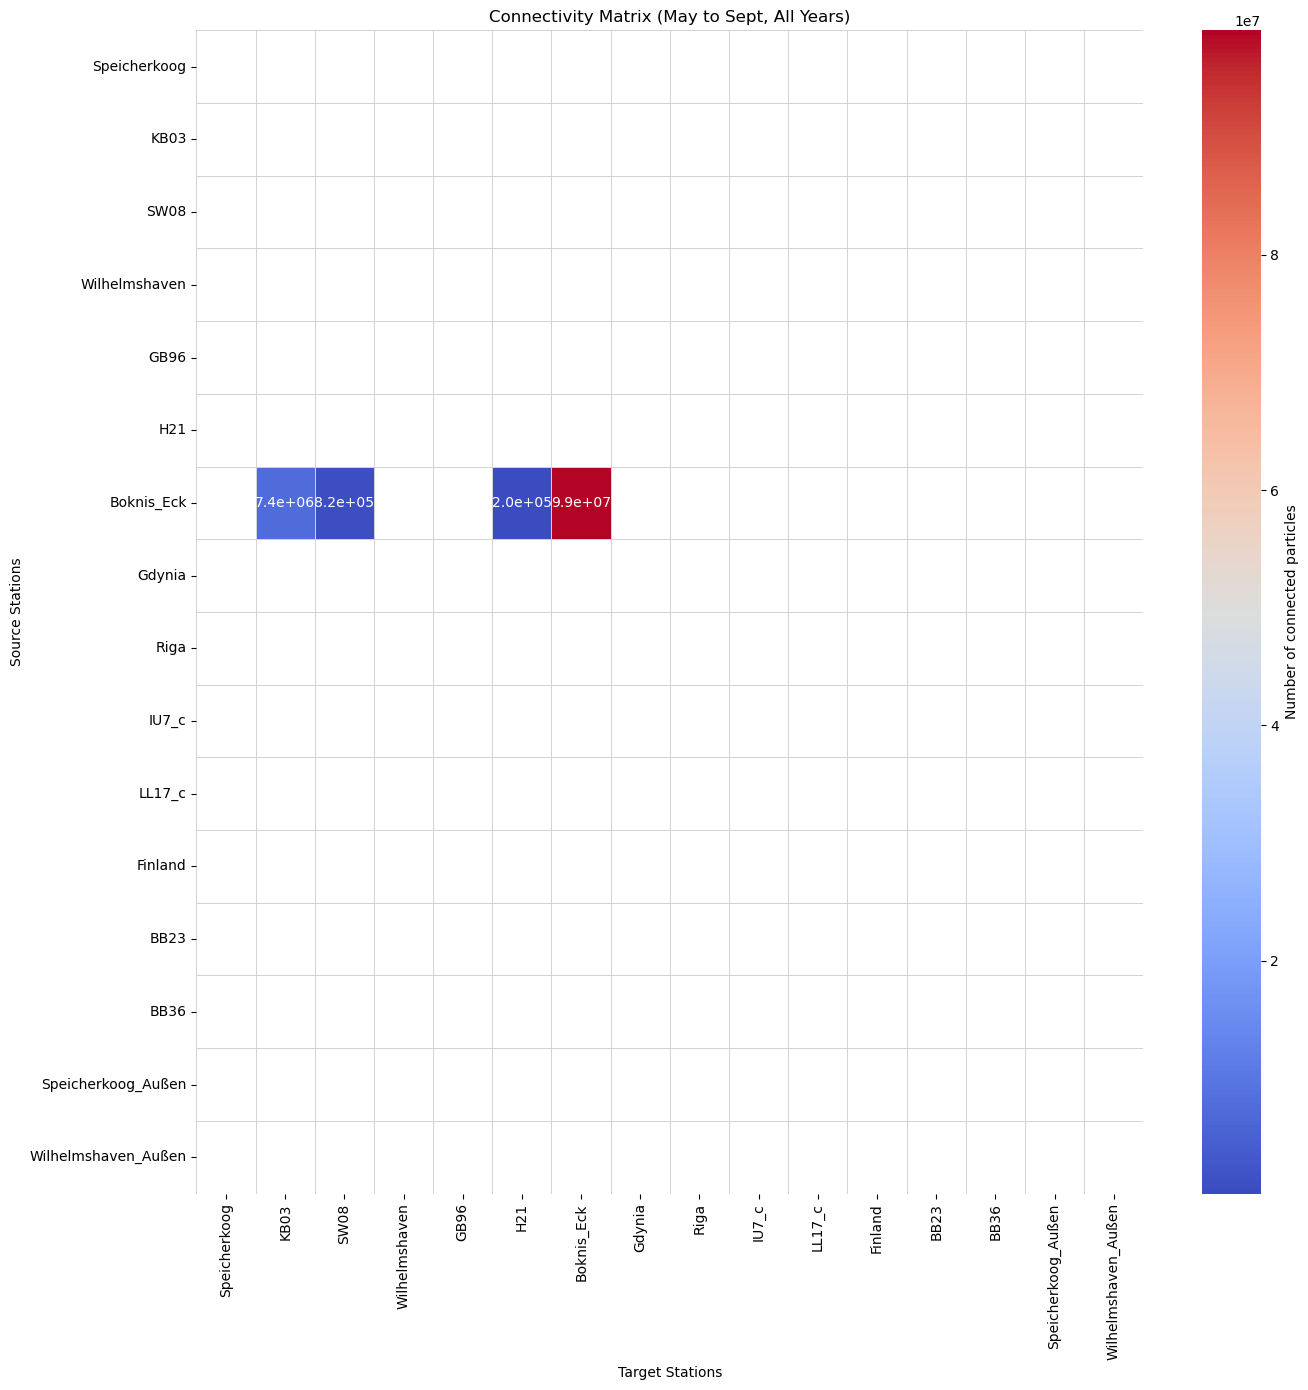

In [18]:
mask = connected_df == 0

# Étape 5 : Heatmap
plt.figure(figsize=(14, 14))
sns.heatmap(connected_df,
             annot=True, 
             fmt=".1e",
             cmap="coolwarm", 
             linecolor="lightgrey",
             cbar_kws={'label': 'Number of connected particles'},
             cbar= True,
             mask = mask,
             linewidths=0.5)
plt.title("Connectivity Matrix (May to Sept, All Years)")
plt.xlabel("Target Stations")
plt.ylabel("Source Stations")
plt.tight_layout()
plt.show()

     
